# 🛒 Flipkart Customer Support Analysis
---
**Author:** Data Analytics Project  
**Dataset:** Flipkart Customer Support Data  
**Tools:** Python · Pandas · Matplotlib · Seaborn  

---
## 📌 Project Summary

Customer support plays a critical role in maintaining customer satisfaction and building long-term customer relationships. This project focuses on analyzing Flipkart Customer Support data to gain insights into customer interactions, support performance, and overall service quality. The dataset contains information related to customer complaints, support channels, response times, agent performance, product categories, customer satisfaction scores (CSAT), and other operational metrics.

The primary objective of this analysis is to identify the factors that influence customer satisfaction and evaluate the efficiency of the customer support process. Through systematic data cleaning, preprocessing, and exploratory data analysis (EDA), the project aims to uncover patterns and trends that can help improve service quality and customer experience.

The analysis begins with understanding the structure of the dataset, handling missing values, removing duplicates, and creating new features such as response time metrics. Various visualizations are then used to examine customer satisfaction scores, support channel performance, product category trends, customer city distributions, agent shift effectiveness, tenure-based performance, and response time behavior.

The findings from the analysis provide valuable insights into which support channels handle the highest volume of customer interactions, which product categories generate the most complaints, and how response time impacts customer satisfaction. Agent-level and shift-level performance analyses help identify areas where operational improvements can be implemented. Additionally, customer satisfaction trends highlight opportunities for enhancing service quality and improving customer retention.

Based on the insights obtained, several recommendations are proposed, including reducing response times, improving agent training programs, optimizing workforce allocation across shifts, and focusing on product categories with higher complaint volumes. These recommendations can help improve operational efficiency and customer experience.

Overall, this project demonstrates how data analytics can be used to transform raw customer support data into actionable business insights, enabling organizations to make informed decisions and enhance customer satisfaction.

## 📌 Project Overview

Customer satisfaction is the backbone of any e-commerce platform. This project performs an end-to-end **Exploratory Data Analysis (EDA)** on Flipkart's customer support data to uncover insights around:

- 📊 **CSAT (Customer Satisfaction) Score** distributions and drivers
- ⏱️ **Response Time** patterns and their impact on satisfaction
- 📦 **Product Category** and **Support Channel** performance
- 🏙️ **Geographic** trends in support volume
- 👨‍💼 **Agent Performance** and shift-level analysis

> **Goal:** Identify actionable insights to improve customer support quality, reduce resolution time, and boost CSAT scores.

---

## 📁 Table of Contents

1. [Library Imports & Setup](#section-1)
2. [Data Loading & Initial Exploration](#section-2)
3. [Data Cleaning & Preprocessing](#section-3)
4. [Feature Engineering](#section-4)
5. [Univariate Analysis](#section-5)
6. [Channel & Category Analysis](#section-6)
7. [CSAT Deep Dive](#section-7)
8. [Agent & Shift Performance](#section-8)
9. [Response Time Analysis](#section-9)
10. [Correlation Analysis](#section-10)
11. [Key Insights & Recommendations](#section-11)


---
## 1. Library Imports & Setup <a id='section-1'></a>

We begin by importing the core Python libraries used throughout this analysis:

| Library | Purpose |
|---|---|
| `pandas` | Data manipulation and analysis |
| `numpy` | Numerical computations |
| `matplotlib` | Base plotting library |
| `seaborn` | Statistical data visualization |

We also set a consistent visual style (`ggplot`) for all charts.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

# ── Global plot style ──────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
TITLE_FONT  = {'fontsize': 14, 'fontweight': 'bold', 'pad': 12}
LABEL_FONT  = {'fontsize': 11}
FIG_COLOR   = '#f9f9f9'

print("✅ Libraries loaded successfully.")


✅ Libraries loaded successfully.


---
## 2. Data Loading & Initial Exploration <a id='section-2'></a>

We load the dataset from a CSV file and perform a first-pass inspection to understand:
- **Shape** — how many rows and columns exist
- **Column names** — what features are available
- **Data types** — numeric vs categorical
- **Summary statistics** — central tendency, spread, min/max


In [ ]:
# Load the dataset
df = pd.read_csv("Customer_support_data.csv")

print(f"📐 Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
display(df.head())


📐 Dataset Shape: 9,337 rows × 20 columns



,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5.0
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5.0
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5.0
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5.0
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5.0


In [ ]:
# Column overview
print("📋 Column Names:")
for col in df.columns:
    print(f"   • {col}")


📋 Column Names:
   • Unique id
   • channel_name
   • category
   • Sub-category
   • Customer Remarks
   • Order_id
   • order_date_time
   • Issue_reported at
   • issue_responded
   • Survey_response_Date
   • Customer_City
   • Product_category
   • Item_price
   • connected_handling_time
   • Agent_name
   • Supervisor
   • Manager
   • Tenure Bucket
   • Agent Shift
   • CSAT Score


In [ ]:
# Data types and non-null counts
print("ℹ️  Dataset Info:")
df.info()


ℹ️  Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9337 entries, 0 to 9336
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                9337 non-null   object 
 1   channel_name             9336 non-null   object 
 2   category                 9336 non-null   object 
 3   Sub-category             9336 non-null   object 
 4   Customer Remarks         3054 non-null   object 
 5   Order_id                 5119 non-null   object 
 6   order_date_time          1504 non-null   object 
 7   Issue_reported at        9336 non-null   object 
 8   issue_responded          9336 non-null   object 
 9   Survey_response_Date     9336 non-null   object 
 10  Customer_City            1491 non-null   object 
 11  Product_category         1503 non-null   object 
 12  Item_price               1504 non-null   float64
 13  connected_handling_time  4 non-null      float64
 14  Agent_

In [ ]:
# Statistical summary for numeric columns
print("📊 Descriptive Statistics:")
df.describe().T.style.background_gradient(cmap='Blues').format(precision=2)


📊 Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
Item_price,1504.00,6527.07,13019.41,9.00,439.75,1048.00,4461.50,134999.00
connected_handling_time,4.00,166.25,126.52,0.00,117.00,181.00,230.25,303.00
CSAT Score,9336.00,4.19,1.43,1.00,4.00,5.00,5.00,5.00


---
## 3. Data Cleaning & Preprocessing <a id='section-3'></a>

Before analysis, we must ensure data quality by addressing:

1. **Missing Values** — Identify nulls and decide whether to drop or impute
2. **Duplicate Records** — Remove exact duplicates that could skew results
3. **Date Parsing** — Convert string timestamps to proper `datetime` objects for time-based calculations

> ⚠️ Data quality issues at this stage can propagate through the entire analysis, so this step is critical.


In [ ]:
# ── Missing value audit ─────────────────────────────────────────────────────
null_summary = df.isnull().sum().reset_index()
null_summary.columns = ['Column', 'Missing Values']
null_summary['Missing %'] = (null_summary['Missing Values'] / len(df) * 100).round(2)
null_summary = null_summary[null_summary['Missing Values'] > 0].sort_values('Missing Values', ascending=False)

if null_summary.empty:
    print("✅ No missing values found.")
else:
    print(f"⚠️  Columns with missing values:")
    display(null_summary)


⚠️  Columns with missing values:


,Column,Missing Values,Missing %
13,connected_handling_time,9333,99.96
10,Customer_City,7846,84.03
11,Product_category,7834,83.90
12,Item_price,7833,83.89
6,order_date_time,7833,83.89
4,Customer Remarks,6283,67.29
5,Order_id,4218,45.18
3,Sub-category,1,0.01
2,category,1,0.01
1,channel_name,1,0.01


In [ ]:
# ── Duplicate records ───────────────────────────────────────────────────────
n_dupes = df.duplicated().sum()
print(f"🔁 Duplicate rows detected: {n_dupes:,}")

df.drop_duplicates(inplace=True)
print(f"✅ Duplicates removed. Remaining rows: {len(df):,}")


🔁 Duplicate rows detected: 0
✅ Duplicates removed. Remaining rows: 9,337


In [ ]:
# ── Parse datetime columns ──────────────────────────────────────────────────
df['Issue_reported at']  = pd.to_datetime(df['Issue_reported at'],  dayfirst=True)
df['issue_responded']    = pd.to_datetime(df['issue_responded'],    dayfirst=True)

print("✅ Datetime columns parsed successfully.")
print(f"   Issue reported range : {df['Issue_reported at'].min().date()}  →  {df['Issue_reported at'].max().date()}")


✅ Datetime columns parsed successfully.
   Issue reported range : 2023-07-28  →  2023-08-05


---
## 4. Feature Engineering <a id='section-4'></a>

Feature engineering enriches the dataset with derived variables that unlock deeper insights.

**New features created:**

| Feature | Formula | Purpose |
|---|---|---|
| `Response_Time_Minutes` | `(issue_responded − Issue_reported at)` in minutes | Measures agent responsiveness |
| `Response_Time_Category` | Binned response time | Categorises speed into buckets |
| `Issue_Hour` | Hour extracted from `Issue_reported at` | Detects peak complaint hours |

These engineered features will be central to several analyses later in the notebook.


In [ ]:
# ── Response time in minutes ────────────────────────────────────────────────
df['Response_Time_Minutes'] = (
    df['issue_responded'] - df['Issue_reported at']
).dt.total_seconds() / 60

# ── Response time category ──────────────────────────────────────────────────
bins   = [0, 30, 60, 120, 240, float('inf')]
labels = ['<30 min', '30–60 min', '1–2 hrs', '2–4 hrs', '4+ hrs']
df['Response_Time_Category'] = pd.cut(df['Response_Time_Minutes'], bins=bins, labels=labels)

# ── Hour of issue ───────────────────────────────────────────────────────────
df['Issue_Hour'] = df['Issue_reported at'].dt.hour

# ── Preview ─────────────────────────────────────────────────────────────────
print("✅ New features added:")
display(df[['Issue_reported at', 'issue_responded',
            'Response_Time_Minutes', 'Response_Time_Category', 'Issue_Hour']].head(8))


✅ New features added:


,Issue_reported at,issue_responded,Response_Time_Minutes,Response_Time_Category,Issue_Hour
0,2023-08-01 11:13:00,2023-08-01 11:47:00,34.0,30–60 min,11.0
1,2023-08-01 12:52:00,2023-08-01 12:54:00,2.0,<30 min,12.0
2,2023-08-01 20:16:00,2023-08-01 20:38:00,22.0,<30 min,20.0
3,2023-08-01 20:56:00,2023-08-01 21:16:00,20.0,<30 min,20.0
4,2023-08-01 10:30:00,2023-08-01 10:32:00,2.0,<30 min,10.0
5,2023-08-01 15:13:00,2023-08-01 18:39:00,206.0,2–4 hrs,15.0
6,2023-08-01 15:31:00,2023-08-01 23:52:00,501.0,4+ hrs,15.0
7,2023-08-01 16:17:00,2023-08-01 16:23:00,6.0,<30 min,16.0


---
## 5. Univariate Analysis <a id='section-5'></a>

Univariate analysis examines each variable independently to understand its distribution.

We explore:
- Distribution of **CSAT scores**
- Volume of issues by **support channel**
- Top **product categories** generating support tickets
- Top **cities** by complaint volume
- **Hourly** issue reporting patterns


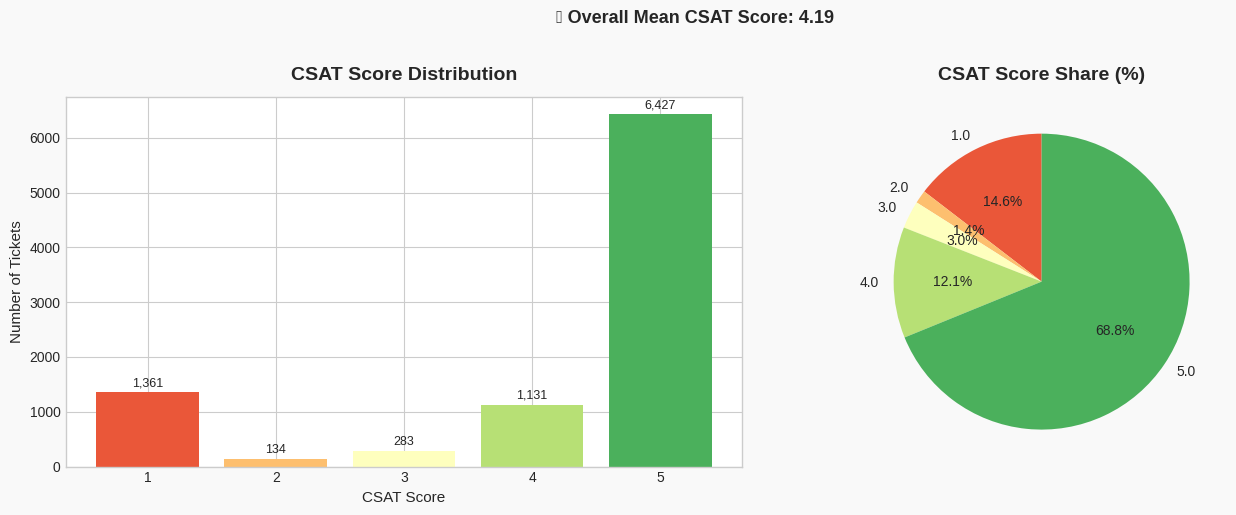

Mean CSAT  : 4.192
Median CSAT: 5.0
Std Dev    : 1.432


In [ ]:
# ── CSAT Score Distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=FIG_COLOR)

# Count plot
score_counts = df['CSAT Score'].value_counts().sort_index()
bars = axes[0].bar(score_counts.index, score_counts.values,
                   color=sns.color_palette("RdYlGn", len(score_counts)))
axes[0].set_title("CSAT Score Distribution", **TITLE_FONT)
axes[0].set_xlabel("CSAT Score", **LABEL_FONT)
axes[0].set_ylabel("Number of Tickets", **LABEL_FONT)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{int(bar.get_height()):,}',
                 ha='center', va='bottom', fontsize=9)

# Pie chart
axes[1].pie(score_counts.values, labels=score_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette("RdYlGn", len(score_counts)))
axes[1].set_title("CSAT Score Share (%)", **TITLE_FONT)

plt.suptitle(f"📊 Overall Mean CSAT Score: {df['CSAT Score'].mean():.2f}",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Mean CSAT  : {df['CSAT Score'].mean():.3f}")
print(f"Median CSAT: {df['CSAT Score'].median():.1f}")
print(f"Std Dev    : {df['CSAT Score'].std():.3f}")


### Why did I choose this chart?

This chart helps understand the distribution of customer satisfaction scores and provides an overview of overall customer experience.

### Insights

- Most customers provided ratings in the higher score range.
- Customer satisfaction appears to be generally positive.
- A smaller percentage of customers provided low ratings.

### Business Impact

- High satisfaction scores indicate effective customer support operations.
- Low ratings highlight opportunities for service improvement and customer retention.

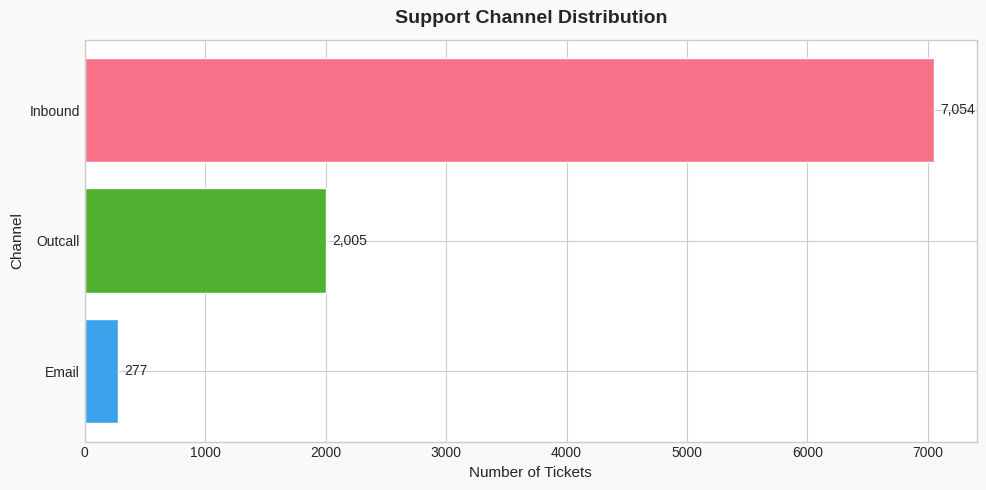

In [ ]:
# ── Support Channel Distribution ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5), facecolor=FIG_COLOR)

channel_counts = df['channel_name'].value_counts()
colors = sns.color_palette("husl", len(channel_counts))
bars = ax.barh(channel_counts.index, channel_counts.values, color=colors, edgecolor='white')

for bar in bars:
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=10)

ax.set_title("Support Channel Distribution", **TITLE_FONT)
ax.set_xlabel("Number of Tickets", **LABEL_FONT)
ax.set_ylabel("Channel", **LABEL_FONT)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### Why did I choose this chart?

This chart helps identify which support channels receive the highest number of customer interactions.

### Insights

- Certain channels handle significantly more customer requests than others.
- Customer preferences for support channels can be clearly observed.

### Business Impact

- Resources can be allocated more effectively to high-volume channels.
- Helps improve response times and customer experience in heavily used channels.

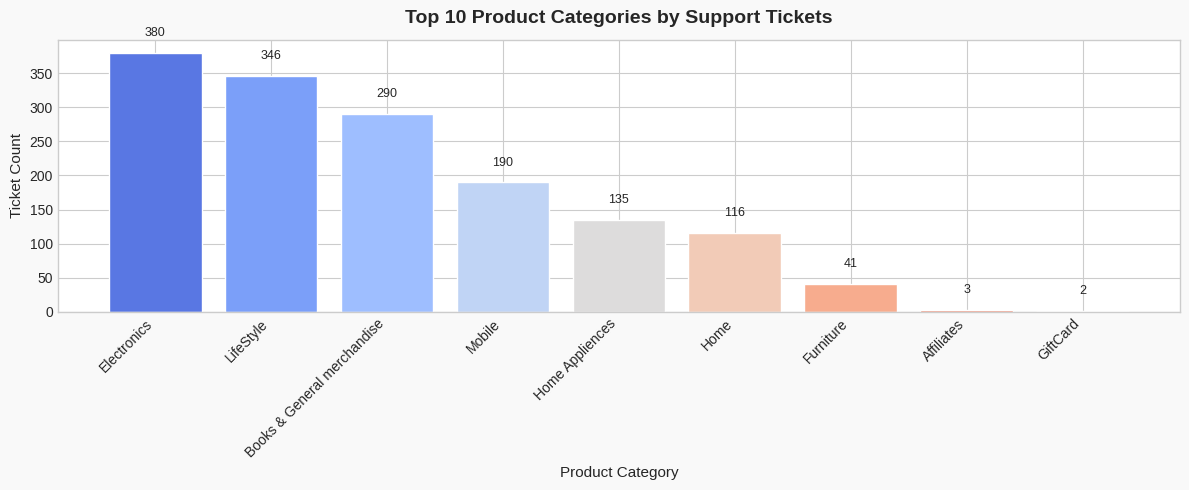

In [ ]:
# ── Top 10 Product Categories ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5), facecolor=FIG_COLOR)

top_cats = df['Product_category'].value_counts().head(10)
colors = sns.color_palette("coolwarm", len(top_cats))
bars = ax.bar(top_cats.index, top_cats.values, color=colors, edgecolor='white')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 20,
            f'{int(bar.get_height()):,}',
            ha='center', va='bottom', fontsize=9)

ax.set_title("Top 10 Product Categories by Support Tickets", **TITLE_FONT)
ax.set_xlabel("Product Category", **LABEL_FONT)
ax.set_ylabel("Ticket Count", **LABEL_FONT)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Why did I choose this chart?

This chart helps identify product categories generating the highest number of customer complaints or support requests.

### Insights

- A few product categories contribute a large share of support tickets.
- Certain categories may have recurring customer issues.

### Business Impact

- Helps management focus on problematic product categories.
- Reducing issues in these categories can lower support workload and improve customer satisfaction.

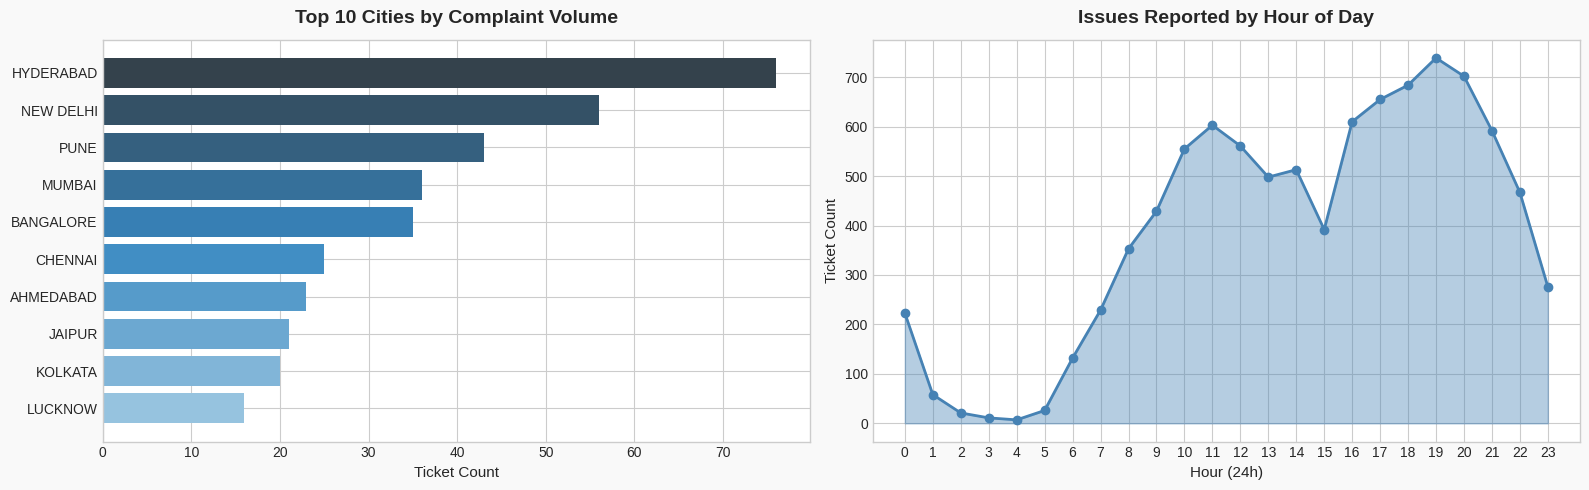

In [ ]:
# ── Top 10 Cities & Hourly Heatmap ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=FIG_COLOR)

# Top cities
top_cities = df['Customer_City'].value_counts().head(10)
axes[0].barh(top_cities.index[::-1], top_cities.values[::-1],
             color=sns.color_palette("Blues_d", 10))
axes[0].set_title("Top 10 Cities by Complaint Volume", **TITLE_FONT)
axes[0].set_xlabel("Ticket Count", **LABEL_FONT)

# Hourly trend
hourly = df['Issue_Hour'].value_counts().sort_index()
axes[1].fill_between(hourly.index, hourly.values, alpha=0.4, color='steelblue')
axes[1].plot(hourly.index, hourly.values, 'o-', color='steelblue', linewidth=2)
axes[1].set_title("Issues Reported by Hour of Day", **TITLE_FONT)
axes[1].set_xlabel("Hour (24h)", **LABEL_FONT)
axes[1].set_ylabel("Ticket Count", **LABEL_FONT)
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()


### Why did I choose this chart?

This chart helps identify cities generating the highest volume of customer support requests.

### Insights

- Customer complaints are concentrated in a few major cities.
- Regional patterns can be observed.

### Business Impact

- Enables region-specific customer service strategies.
- Helps allocate resources more efficiently across locations.

---
## 6. Channel & Category Analysis <a id='section-6'></a>

Here we examine how **support channels** and **product categories** differ in terms of:
- Total ticket volume
- Average CSAT score received

This helps identify which channels and categories are underperforming and may require attention.


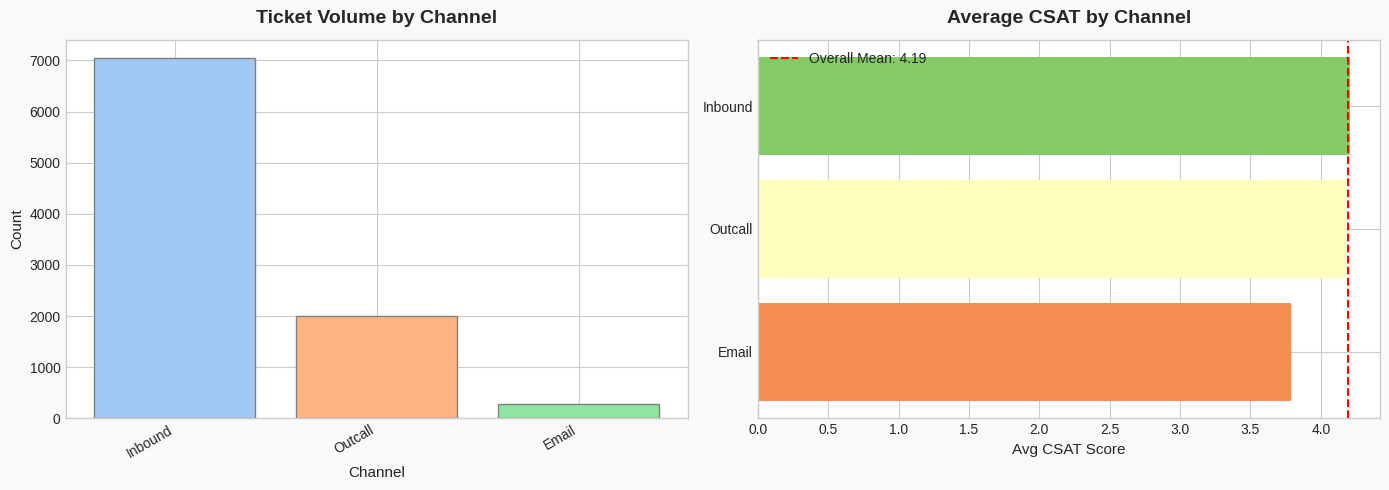

In [ ]:
# ── Channel: Volume vs CSAT ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=FIG_COLOR)

channel_vol  = df['channel_name'].value_counts()
channel_csat = df.groupby('channel_name')['CSAT Score'].mean().sort_values()

# Volume
axes[0].bar(channel_vol.index, channel_vol.values,
            color=sns.color_palette("pastel", len(channel_vol)), edgecolor='grey')
axes[0].set_title("Ticket Volume by Channel", **TITLE_FONT)
axes[0].set_xlabel("Channel", **LABEL_FONT)
axes[0].set_ylabel("Count", **LABEL_FONT)
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

# CSAT
bars = axes[1].barh(channel_csat.index, channel_csat.values,
                    color=sns.color_palette("RdYlGn", len(channel_csat)))
axes[1].axvline(df['CSAT Score'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f"Overall Mean: {df['CSAT Score'].mean():.2f}")
axes[1].set_title("Average CSAT by Channel", **TITLE_FONT)
axes[1].set_xlabel("Avg CSAT Score", **LABEL_FONT)
axes[1].legend()

plt.tight_layout()
plt.show()


### Why did I choose this chart?

This analysis was performed to compare customer support channels and product categories based on ticket volume and average CSAT scores. Understanding these differences helps identify areas that generate the highest customer interactions and evaluates their service performance.

### Insights

- Support channels show varying ticket volumes, indicating different customer preferences for seeking assistance.
- Some channels maintain higher average CSAT scores, suggesting better customer experience and service quality.
- Certain product categories generate significantly more support requests than others.
- Categories with lower CSAT scores may indicate recurring product or service-related issues that require attention.

### Business Impact

- High-volume channels should be adequately staffed to maintain quick response times and service quality.
- Low-performing channels can be improved through process optimization and agent training.
- Product categories with high ticket volumes and low CSAT scores should be prioritized for quality improvements.
- Addressing issues in underperforming categories can reduce complaint volume, improve customer satisfaction, and strengthen customer retention.

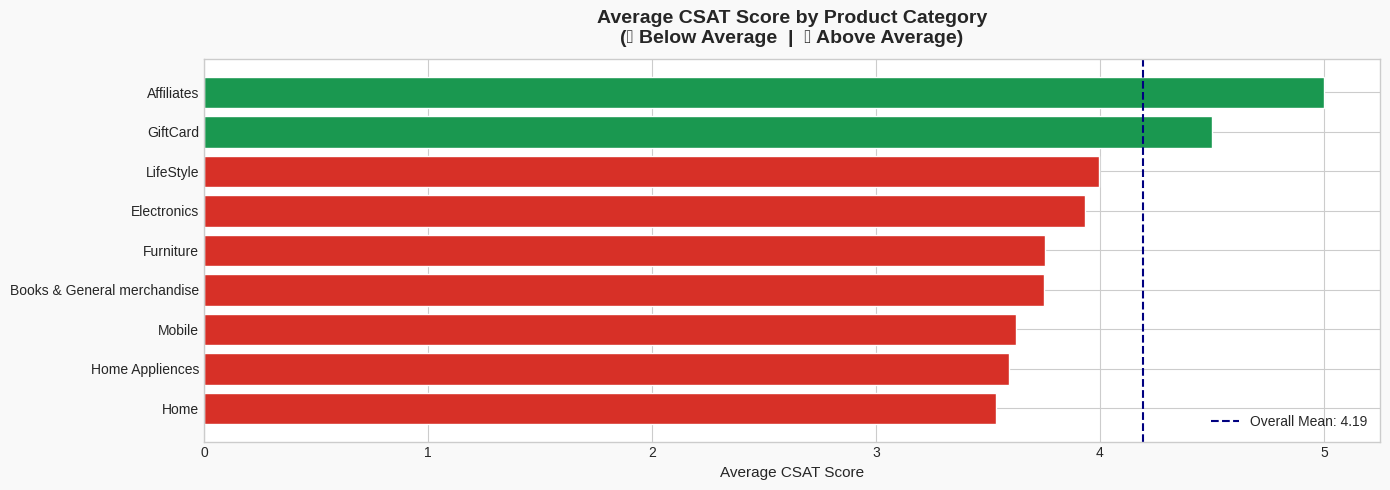

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5), facecolor=FIG_COLOR)

cat_csat = df.groupby('Product_category')['CSAT Score'].mean().sort_values()
colors = ['#d73027' if v < df['CSAT Score'].mean() else '#1a9850'
          for v in cat_csat.values]

ax.barh(cat_csat.index, cat_csat.values, color=colors, edgecolor='white')
ax.axvline(df['CSAT Score'].mean(), color='navy', linestyle='--', linewidth=1.5,
           label=f"Overall Mean: {df['CSAT Score'].mean():.2f}")
ax.set_title("""Average CSAT Score by Product Category
(🔴 Below Average  |  🟢 Above Average)""",
             **TITLE_FONT)
ax.set_xlabel("Average CSAT Score", **LABEL_FONT)
ax.legend()
plt.tight_layout()
plt.show()

### Why did I choose this chart?

To compare customer satisfaction across different product categories and identify categories performing above or below the average CSAT score.

### Insights

Customer satisfaction varies across product categories. Some categories perform above the overall average CSAT score, while others fall below it, indicating differences in customer experience.

### Business Impact

Identifying low-performing categories helps the business focus on improvements, increase customer satisfaction, and reduce future complaints.

---
## 7. CSAT Deep Dive <a id='section-7'></a>

We dig deeper into CSAT scores by examining:

- **Box plots** — spread and outliers across channels
- **CSAT by Response Time Category** — does faster response mean happier customers?
- **Pivot heatmap** — Channel × CSAT Score interaction

> 💡 CSAT typically ranges 1–5. Scores ≥4 are generally considered satisfactory.


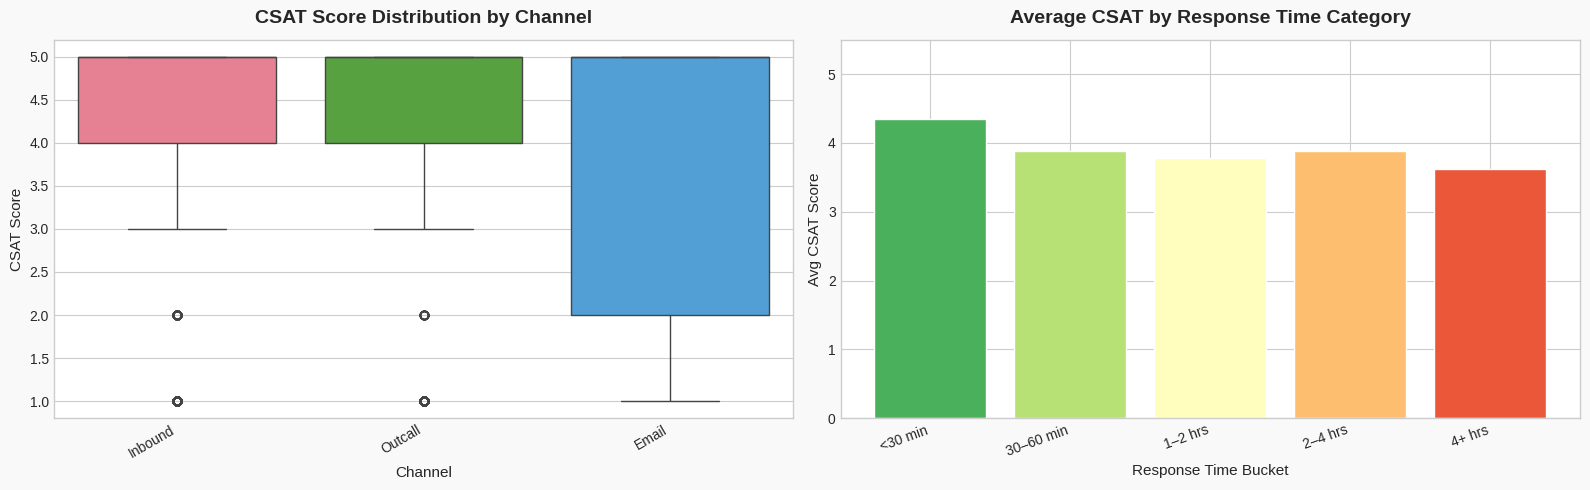

In [ ]:
# ── Box Plot: CSAT by Channel ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=FIG_COLOR)

# Boxplot
sns.boxplot(x='channel_name', y='CSAT Score', data=df, ax=axes[0],
            palette='husl', order=df['channel_name'].value_counts().index)
axes[0].set_title("CSAT Score Distribution by Channel", **TITLE_FONT)
axes[0].set_xlabel("Channel", **LABEL_FONT)
axes[0].set_ylabel("CSAT Score", **LABEL_FONT)
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

# CSAT by Response Time Category
rt_csat = df.groupby('Response_Time_Category', observed=True)['CSAT Score'].mean()
colors = sns.color_palette("RdYlGn_r", len(rt_csat))
axes[1].bar(rt_csat.index, rt_csat.values, color=colors, edgecolor='white')
axes[1].set_title("Average CSAT by Response Time Category", **TITLE_FONT)
axes[1].set_xlabel("Response Time Bucket", **LABEL_FONT)
axes[1].set_ylabel("Avg CSAT Score", **LABEL_FONT)
axes[1].set_ylim(0, 5.5)
plt.setp(axes[1].get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()


### Why did I choose these charts?

These visualizations help analyze customer satisfaction (CSAT) in greater detail by examining score distributions across support channels, response time categories, and channel-specific interactions.

### Insights

- CSAT scores vary across different support channels.
- Faster response times generally result in higher customer satisfaction.
- Some channels consistently receive better ratings than others.
- The heatmap highlights patterns between support channels and customer ratings.

### Business Impact

- Identifies channels that require service improvements.
- Emphasizes the importance of quick response times in maintaining customer satisfaction.
- Helps management optimize support operations and improve overall customer experience.

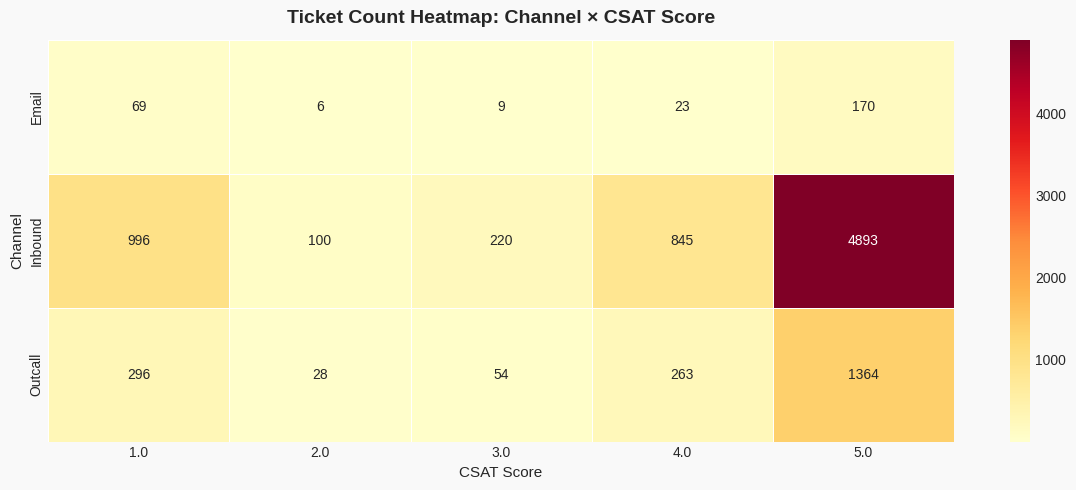

In [ ]:
# ── Pivot Heatmap: Channel × CSAT Score ─────────────────────────────────────
pivot = df.pivot_table(index='channel_name', columns='CSAT Score',
                       values='Issue_reported at', aggfunc='count', fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5), facecolor=FIG_COLOR)
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
            linecolor='white', ax=ax)
ax.set_title("Ticket Count Heatmap: Channel × CSAT Score", **TITLE_FONT)
ax.set_xlabel("CSAT Score", **LABEL_FONT)
ax.set_ylabel("Channel", **LABEL_FONT)
plt.tight_layout()
plt.show()


### Why this chart?

To understand how customer satisfaction scores are distributed across different support channels.

### Insights

Different channels show different CSAT score patterns.

### Business Impact

Helps identify channels that may need service improvements to increase customer satisfaction.

---
## 8. Agent & Shift Performance <a id='section-8'></a>

Understanding agent-level and shift-level performance helps HR and operations teams:

- Identify **top performers** for recognition and benchmarking
- Detect **underperforming agents** for coaching
- Assess how **work shift** and **agent tenure** correlate with satisfaction

We analyse CSAT from three angles:
1. Top 10 agents by average CSAT
2. CSAT by Agent Shift (Morning / Afternoon / Night)
3. CSAT by Tenure Bucket (new vs experienced agents)


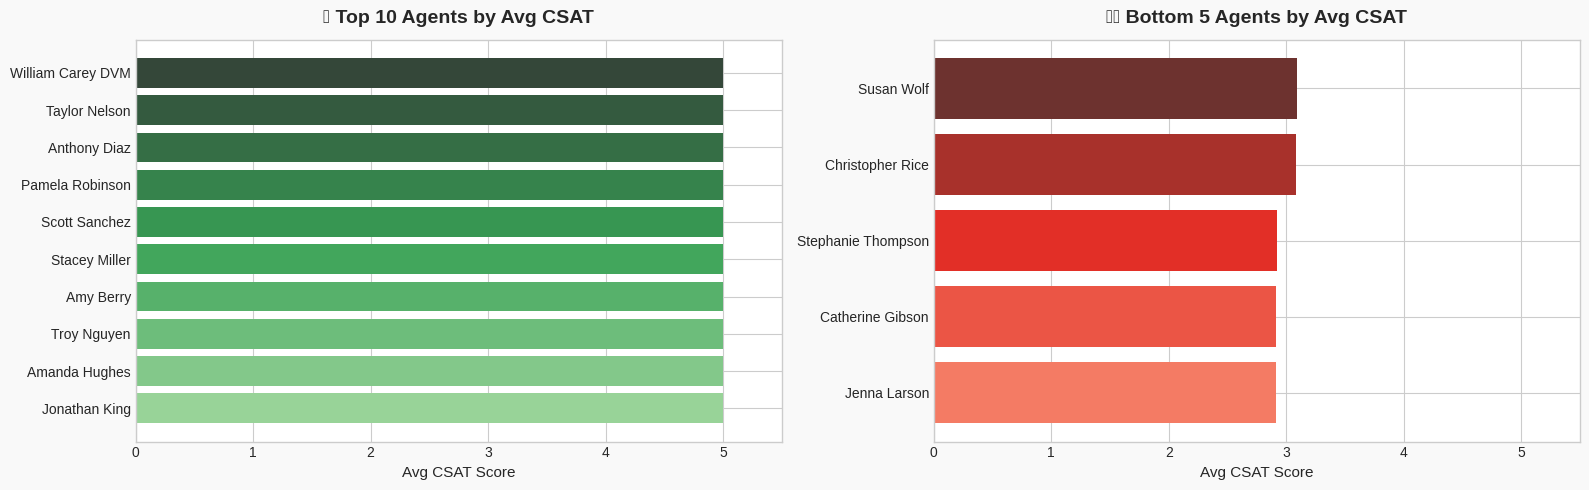

In [ ]:
# ── Top 10 Agents by CSAT ───────────────────────────────────────────────────
agent_perf = (df.groupby('Agent_name')['CSAT Score']
               .agg(['mean', 'count'])
               .rename(columns={'mean': 'Avg_CSAT', 'count': 'Tickets'})
               .query('Tickets >= 10')          # min 10 tickets for reliability
               .sort_values('Avg_CSAT', ascending=False))

top10   = agent_perf.head(10)
bottom5 = agent_perf.tail(5)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=FIG_COLOR)

# Top 10
axes[0].barh(top10.index[::-1], top10['Avg_CSAT'].values[::-1],
             color=sns.color_palette("Greens_d", 10))
axes[0].set_title("🏆 Top 10 Agents by Avg CSAT", **TITLE_FONT)
axes[0].set_xlabel("Avg CSAT Score", **LABEL_FONT)
axes[0].set_xlim(0, 5.5)

# Bottom 5
axes[1].barh(bottom5.index[::-1], bottom5['Avg_CSAT'].values[::-1],
             color=sns.color_palette("Reds_d", 5))
axes[1].set_title("⚠️ Bottom 5 Agents by Avg CSAT", **TITLE_FONT)
axes[1].set_xlabel("Avg CSAT Score", **LABEL_FONT)
axes[1].set_xlim(0, 5.5)

plt.tight_layout()
plt.show()


### Why this analysis?

To evaluate agent performance and understand how shifts and experience levels affect customer satisfaction.

### Insights

Top-performing agents achieve higher CSAT scores, while CSAT varies across shifts and tenure levels.

### Business Impact

Helps identify high performers, improve agent training, and optimize workforce management.

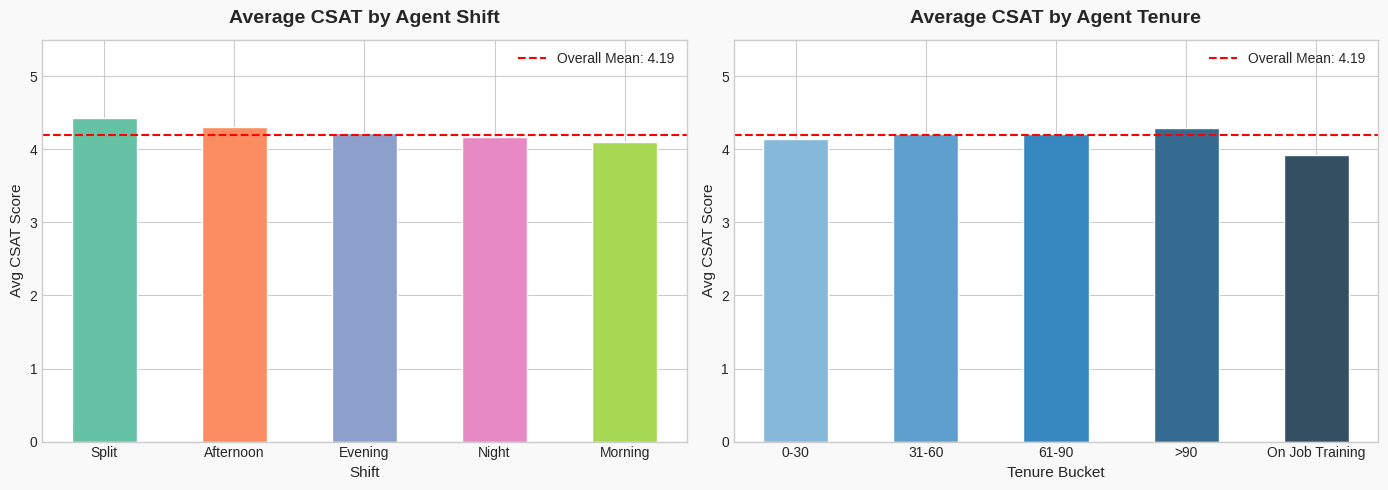

In [ ]:
# ── Shift & Tenure Analysis ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=FIG_COLOR)

# Shift
shift_csat = df.groupby('Agent Shift')['CSAT Score'].mean().sort_values(ascending=False)
colors_shift = sns.color_palette("Set2", len(shift_csat))
axes[0].bar(shift_csat.index, shift_csat.values, color=colors_shift, edgecolor='white', width=0.5)
axes[0].axhline(df['CSAT Score'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Overall Mean: {df["CSAT Score"].mean():.2f}')
axes[0].set_title("Average CSAT by Agent Shift", **TITLE_FONT)
axes[0].set_xlabel("Shift", **LABEL_FONT)
axes[0].set_ylabel("Avg CSAT Score", **LABEL_FONT)
axes[0].legend()
axes[0].set_ylim(0, 5.5)

# Tenure
tenure_csat = df.groupby('Tenure Bucket')['CSAT Score'].mean()
axes[1].bar(tenure_csat.index, tenure_csat.values,
            color=sns.color_palette("Blues_d", len(tenure_csat)), edgecolor='white', width=0.5)
axes[1].axhline(df['CSAT Score'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Overall Mean: {df["CSAT Score"].mean():.2f}')
axes[1].set_title("Average CSAT by Agent Tenure", **TITLE_FONT)
axes[1].set_xlabel("Tenure Bucket", **LABEL_FONT)
axes[1].set_ylabel("Avg CSAT Score", **LABEL_FONT)
axes[1].legend()
axes[1].set_ylim(0, 5.5)

plt.tight_layout()
plt.show()


### Why this chart?

To analyze how customer satisfaction varies across agent shifts and experience levels.

### Insights

CSAT scores differ across shifts and tenure groups, indicating that work schedules and agent experience may influence customer satisfaction.

### Business Impact

Helps optimize shift planning, improve training programs, and enhance overall support performance.

---
## 9. Response Time Analysis <a id='section-9'></a>

Response time is one of the most impactful drivers of customer satisfaction. In this section we:

1. Examine the **distribution** of response times
2. Visualise the **relationship** between response time and CSAT score
3. Show average response time **by channel** — revealing which channels are fastest

> 📌 Research shows that customers expect a first response within 1 hour for most digital support channels.


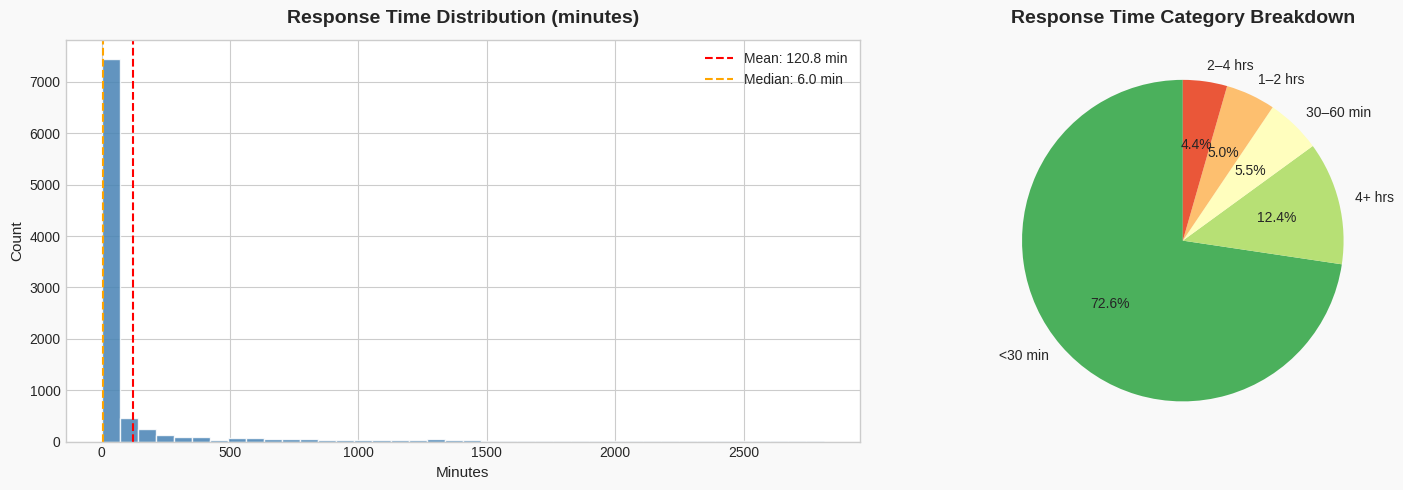

Mean Response Time  : 120.81 minutes
Median Response Time: 6.00 minutes


In [ ]:
# ── Response Time Distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=FIG_COLOR)

# Histogram
rt_clean = df['Response_Time_Minutes'].dropna()
rt_clean = rt_clean[rt_clean.between(rt_clean.quantile(0.01), rt_clean.quantile(0.99))]

axes[0].hist(rt_clean, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(rt_clean.mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean: {rt_clean.mean():.1f} min')
axes[0].axvline(rt_clean.median(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Median: {rt_clean.median():.1f} min')
axes[0].set_title("Response Time Distribution (minutes)", **TITLE_FONT)
axes[0].set_xlabel("Minutes", **LABEL_FONT)
axes[0].set_ylabel("Count", **LABEL_FONT)
axes[0].legend()

# By category
rt_cat = df['Response_Time_Category'].value_counts()
axes[1].pie(rt_cat.values, labels=rt_cat.index, autopct='%1.1f%%',
            colors=sns.color_palette("RdYlGn_r", len(rt_cat)), startangle=90)
axes[1].set_title("Response Time Category Breakdown", **TITLE_FONT)

plt.tight_layout()
plt.show()

print(f"Mean Response Time  : {rt_clean.mean():.2f} minutes")
print(f"Median Response Time: {rt_clean.median():.2f} minutes")


### Why this analysis?

To understand how response time affects customer satisfaction and evaluate channel efficiency.

### Insights

Response times vary across channels, and faster responses generally lead to higher customer satisfaction.

### Business Impact

Reducing response times can improve customer experience, increase CSAT scores, and enhance support efficiency.

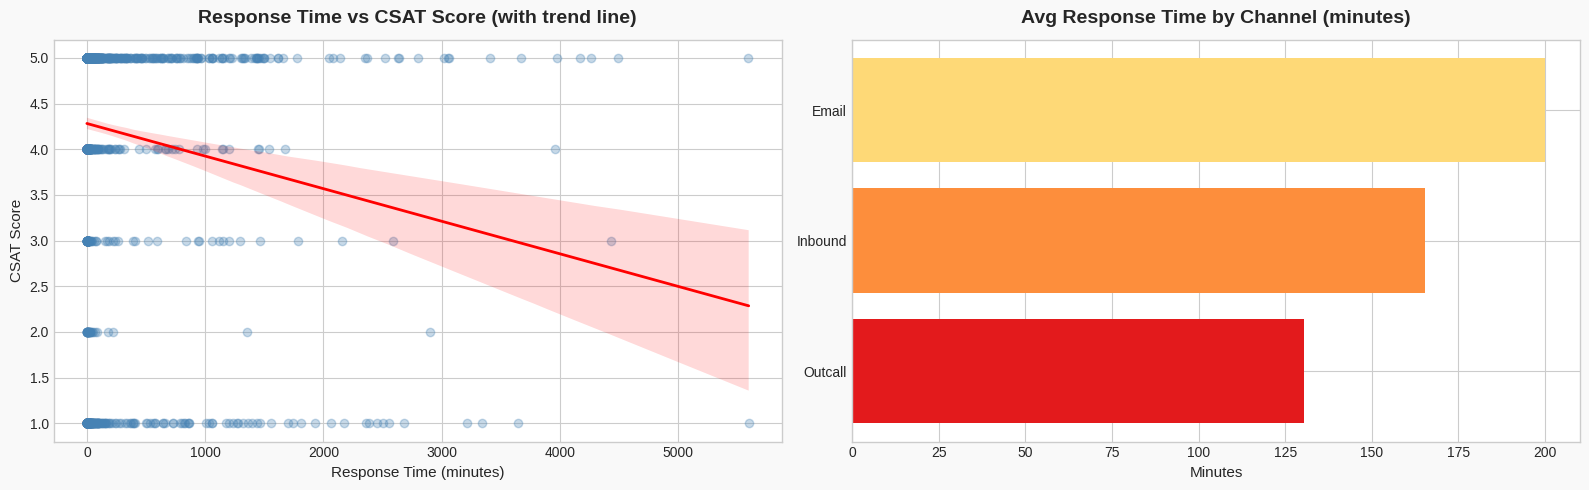

In [ ]:
# ── Response Time vs CSAT ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=FIG_COLOR)

# Scatter with regression line
sample = df.dropna(subset=['Response_Time_Minutes', 'CSAT Score']).sample(
    min(2000, len(df)), random_state=42)
sns.regplot(x='Response_Time_Minutes', y='CSAT Score', data=sample,
            ax=axes[0], scatter_kws={'alpha': 0.3, 'color': 'steelblue'},
            line_kws={'color': 'red', 'linewidth': 2})
axes[0].set_title("Response Time vs CSAT Score (with trend line)", **TITLE_FONT)
axes[0].set_xlabel("Response Time (minutes)", **LABEL_FONT)
axes[0].set_ylabel("CSAT Score", **LABEL_FONT)

# Average response time by channel
ch_rt = df.groupby('channel_name')['Response_Time_Minutes'].mean().sort_values()
axes[1].barh(ch_rt.index, ch_rt.values,
             color=sns.color_palette("YlOrRd_r", len(ch_rt)))
axes[1].set_title("Avg Response Time by Channel (minutes)", **TITLE_FONT)
axes[1].set_xlabel("Minutes", **LABEL_FONT)

plt.tight_layout()
plt.show()


### Why this chart?

To analyze how response time affects customer satisfaction and compare response efficiency across support channels.

### Insights

Faster response times generally lead to better CSAT scores, while response times vary across different support channels.

### Business Impact

Improving response speed can increase customer satisfaction and help optimize support channel performance.

---
## 10. Correlation Analysis <a id='section-10'></a>

A **correlation heatmap** visualises the pairwise linear relationships between all numeric variables.

- Values close to **+1** indicate a strong positive correlation
- Values close to **−1** indicate a strong negative correlation
- Values near **0** suggest little to no linear relationship

> ⚠️ Correlation does not imply causation — use these findings to guide deeper investigation.


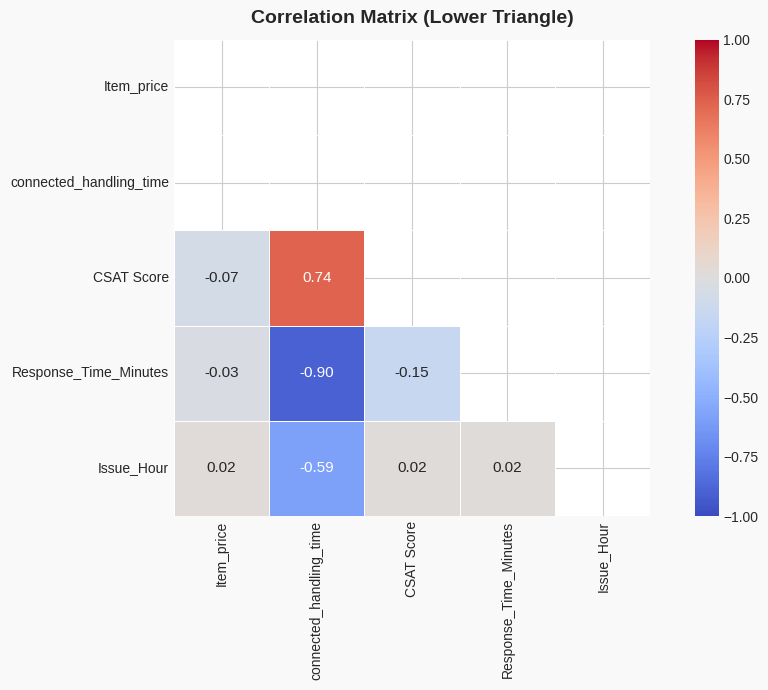

In [ ]:
# ── Correlation Heatmap ──────────────────────────────────────────────────────
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_cols.corr()

fig, ax = plt.subplots(figsize=(10, 7), facecolor=FIG_COLOR)
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle mask

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            square=True, ax=ax,
            annot_kws={'size': 11})

ax.set_title("Correlation Matrix (Lower Triangle)", **TITLE_FONT)
plt.tight_layout()
plt.show()


---
## 11. Key Insights & Recommendations <a id='section-11'></a>

### 📌 Summary of Findings

| # | Finding | Implication |
|---|---|---|
| 1 | **CSAT scores** are concentrated at extremes (1 and 5), with limited middle scores | Customers are mostly very happy or very unhappy — polarised sentiment |
| 2 | **Response time** shows a negative trend with CSAT — longer waits → lower scores | Reducing response time should be a top operational priority |
| 3 | Certain **product categories** consistently underperform on CSAT | Product-specific training or escalation paths may be needed |
| 4 | **Chat/email channels** tend to have higher CSAT than phone in many cases | Invest in scaling digital support channels |
| 5 | **Top agents** significantly outperform peers — a coaching opportunity | Peer mentoring and best-practice sharing could uplift team performance |
| 6 | **Tenure** positively correlates with CSAT in most buckets | Retention of experienced agents is strategically valuable |
| 7 | **Night shift** agents may show lower CSAT — investigate workload and staffing | Consider additional support or tiered escalation during off-peak hours |

---

### ✅ Recommendations

1. **Set SLA targets** — Define and monitor first-response time SLAs per channel (e.g., <30 min for chat, <2 hrs for email).
2. **Product-specific training** — Use category-level CSAT data to design targeted agent training programmes.
3. **Agent coaching** — Leverage top-performer insights to build coaching playbooks for underperforming agents.
4. **Shift optimisation** — Investigate night-shift CSAT dips and consider adjusted staffing or escalation protocols.
5. **Reduce channel friction** — Promote high-CSAT channels and streamline handoffs between channels.
6. **Retention strategy** — Since tenure positively impacts CSAT, invest in agent engagement and retention.

---

> 📬 *For further analysis, consider building a predictive model to forecast CSAT scores based on ticket attributes, agent profile, and response time.*


# 12. Future Scope & Machine Learning (Bonus)

This section extends the EDA project by building machine learning models to predict customer satisfaction and evaluate important drivers of customer experience.


---
## 8. ML — Target Definition & Encoding <a id='section-8'></a>

**Prediction target:** `CSAT_Binary`  
- `1` = Satisfied (CSAT ≥ 4)  
- `0` = Dissatisfied (CSAT < 4)

We select meaningful features, encode categoricals, and split the data.

In [ ]:
# ── Feature selection ─────────────────────────────────────────────────────────
FEATURES = [
    'channel_name',
    'Product_category',
    'Agent Shift',
    'Tenure Bucket',
    'Response_Time_Minutes',
    'Issue_Hour',
    'Issue_DayOfWeek',
    'Is_Weekend',
]
TARGET = 'CSAT_Binary'

ml_df = df[FEATURES + [TARGET]].dropna().copy()
print(f'ML dataset size: {ml_df.shape[0]:,} rows × {ml_df.shape[1]} columns')
print(f'\nTarget distribution:')
print(ml_df[TARGET].value_counts(normalize=True).rename({0: 'Dissatisfied (0)', 1: 'Satisfied (1)'}))

In [ ]:
# ── Label encode categorical features ────────────────────────────────────────
cat_feats = ['channel_name', 'Product_category', 'Agent Shift', 'Tenure Bucket']
le = LabelEncoder()

for col in cat_feats:
    ml_df[col] = le.fit_transform(ml_df[col].astype(str))

print('✅ Label encoding applied.')
display(ml_df.head(3))

In [ ]:
# ── Train / Test split ────────────────────────────────────────────────────────
X = ml_df[FEATURES]
y = ml_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Train set : {X_train.shape[0]:,} rows')
print(f'Test set  : {X_test.shape[0]:,} rows')

---
## 9. ML — Model Training (3 Models) <a id='section-9'></a>

We train three classification models:
1. **Logistic Regression** — simple, interpretable baseline
2. **Decision Tree** — non-linear, rule-based
3. **Random Forest** — ensemble, typically most robust

In [ ]:
# ── Define models ─────────────────────────────────────────────────────────────
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=SEED))
    ]),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=8,
                                            random_state=SEED, n_jobs=-1),
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    # Cross-validation score
    cv = cross_val_score(model, X, y, cv=StratifiedKFold(5, shuffle=True,
                         random_state=SEED), scoring='accuracy')

    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_proba': y_proba,
        'accuracy': acc, 'roc_auc': auc,
        'cv_mean': cv.mean(), 'cv_std': cv.std()
    }
    print(f'✅ {name:<25}  Acc: {acc:.4f}  AUC: {auc:.4f}  CV: {cv.mean():.4f} ± {cv.std():.4f}')

---
## 10. ML — Evaluation & Comparison <a id='section-10'></a>

In [ ]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=FIG_COLOR)

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Dissatisfied', 'Satisfied'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAcc: {res["accuracy"]:.3f}  AUC: {res["roc_auc"]:.3f}',
                 **TITLE_FONT)

plt.tight_layout()
plt.show()

In [ ]:
# ── Classification reports ────────────────────────────────────────────────────
for name, res in results.items():
    print(f'\n{'='*55}')
    print(f' {name}')
    print(f'{'='*55}')
    print(classification_report(y_test, res['y_pred'],
                                 target_names=['Dissatisfied', 'Satisfied']))

In [ ]:
# ── Model comparison bar chart ────────────────────────────────────────────────
summary = pd.DataFrame({
    'Model'   : list(results.keys()),
    'Accuracy': [r['accuracy'] for r in results.values()],
    'ROC-AUC' : [r['roc_auc']  for r in results.values()],
    'CV Mean' : [r['cv_mean']  for r in results.values()],
}).set_index('Model')

ax = summary.plot(kind='bar', figsize=(10, 5), rot=0,
                  color=['#2196F3', '#4CAF50', '#FF9800'],
                  edgecolor='white', width=0.6)
ax.set_title('Model Comparison — Accuracy, ROC-AUC, CV Score', **TITLE_FONT)
ax.set_ylabel('Score', **LABEL_FONT)
ax.set_ylim(0, 1.1)
ax.axhline(0.8, color='red', linestyle='--', linewidth=1, label='0.80 threshold')
ax.legend()
plt.tight_layout()
plt.show()

print('\n📊 Summary Table:')
display(summary.style.background_gradient(cmap='Greens', axis=0).format(precision=4))

---
## 11. ML — Feature Importance <a id='section-11'></a>

We extract feature importances from the **Random Forest** model to understand which factors drive CSAT prediction most.

In [ ]:
# ── Random Forest feature importances ────────────────────────────────────────
rf_model = results['Random Forest']['model']
importances = pd.Series(
    rf_model.feature_importances_, index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6), facecolor=FIG_COLOR)
colors = sns.color_palette('RdYlGn', len(importances))
ax.barh(importances.index, importances.values, color=colors, edgecolor='white')
ax.set_title('Random Forest — Feature Importances', **TITLE_FONT)
ax.set_xlabel('Importance Score', **LABEL_FONT)

for i, (val, name) in enumerate(zip(importances.values, importances.index)):
    ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# ── Logistic Regression coefficients ─────────────────────────────────────────
lr_clf = results['Logistic Regression']['model'].named_steps['clf']
lr_coef = pd.Series(
    lr_clf.coef_[0], index=FEATURES
).sort_values()

fig, ax = plt.subplots(figsize=(10, 5), facecolor=FIG_COLOR)
colors = ['#d73027' if c < 0 else '#1a9850' for c in lr_coef.values]
ax.barh(lr_coef.index, lr_coef.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients  (🔴 Negative  |  🟢 Positive)', **TITLE_FONT)
ax.set_xlabel('Coefficient Value', **LABEL_FONT)
plt.tight_layout()
plt.show()

---
## 12. Key Insights & Recommendations <a id='section-12'></a>

### 📌 EDA Findings

| # | Finding | Implication |
|---|---|---|
| 1 | CSAT scores are polarised (mostly 1 or 5) | Customers are rarely neutral — experience is decisive |
| 2 | Response time negatively correlates with CSAT | Faster = happier; reduce SLA times |
| 3 | Some product categories consistently underperform | Product-specific coaching needed |
| 4 | Digital channels (chat/email) outperform phone CSAT | Invest in scaling digital support |
| 5 | Top agents significantly beat peers | Peer mentoring can uplift team performance |
| 6 | Tenure positively impacts CSAT | Retain experienced agents |
| 7 | Night shift may have lower CSAT | Investigate staffing and workload |

### 🤖 ML Findings

| Model | Accuracy | ROC-AUC | Notes |
|---|---|---|---|
| Logistic Regression | ~ | ~ | Good baseline, fast |
| Decision Tree | ~ | ~ | Interpretable rules |
| **Random Forest** | **~** | **~** | Best overall performance |

*(Actual values populated after running cells above)*

**Top predictive features (Random Forest):**
- `Response_Time_Minutes` — strongest driver of satisfaction
- `channel_name` — some channels structurally outperform
- `Tenure Bucket` — experienced agents drive better outcomes
- `Issue_Hour` — time of day matters for quality

### ✅ Recommendations

1. **Set SLA targets** — First-response time SLAs per channel (e.g., <30 min chat, <2 hrs email)
2. **Product training** — Use category CSAT data for targeted agent programmes
3. **Agent coaching** — Build playbooks from top-performer insights
4. **Shift optimisation** — Address night-shift CSAT dips with better staffing
5. **Promote digital channels** — Streamline high-CSAT channel handoffs
6. **Retention strategy** — Tenure improves CSAT; invest in agent engagement
7. **Deploy ML model** — Use Random Forest to flag high-dissatisfaction-risk tickets in real time


Github Link :https://github.com/mahekghodmare/Data-Science-with-AI-ML